# ДЗ №7. Postprocessing и error analysis LLM-distillation pipeline

## 1. Цель работы

В этом notebook анализируется LLM-distillation pipeline из ДЗ №5–6. LLM используется как teacher: она размечает train-объекты и возвращает `label` и `confidence`. Затем `label` и `confidence` преобразуются в soft labels, на которых обучается compact student-модель `TF-IDF + LogisticRegression`.

В ДЗ №7 мы анализируем ошибки student-модели на valid, дорабатываем teacher prompt, заново получаем teacher labels для train, переобучаем student-модель и проверяем, улучшилось ли качество. После этого выполняется postprocessing предсказаний student-модели через threshold и review-zone.

```text
teacher prompt -> LLM teacher labels on train -> soft_y -> student model -> valid/test predictions
```


## 2. Связь с ДЗ №5-6

В ДЗ №5-6 уже был реализован teacher prompt `build_llm_teacher_prompt_short`, получение teacher labels для train и обучение compact student-модели. В ДЗ №7 эта логика используется как основа: prompt v1 берётся из ДЗ №5-6, затем по ошибкам `student v1` на valid формируется refined teacher prompt `v2b`.

Важно: LLM не классифицирует valid/test напрямую. Teacher labels используются только для train, а valid/test оцениваются по predictions student-модели и true target `alert_flag`.


## 3. Validation protocol

Train используется для teacher-разметки и обучения student-моделей. Valid используется для анализа ошибок, доработки teacher prompt и выбора postprocessing. Test используется только один раз для финальной проверки выбранной схемы. Нельзя использовать test для доработки prompt, выбора threshold или review-zone.


## 4. Загрузка данных


In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import FeatureUnion

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
RUN_LLM_API = False
ALPHA_VALUES = [0.2, 0.3, 0.5]
C_VALUES = [0.5, 1.0, 2.0, 5.0]

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

DATA_PATH = PROJECT_ROOT / "homework_04_dataset" / "data" / "dataset_for_training.csv"
HW7_DIR = PROJECT_ROOT / "homework_07_postprocessing"
TEACHER_DIR = HW7_DIR / "reports" / "teacher_labels"
STUDENT_PRED_DIR = HW7_DIR / "reports" / "student_predictions"
ERROR_DIR = HW7_DIR / "reports" / "error_analysis"
FIG_DIR = HW7_DIR / "reports" / "figures"

for path in [TEACHER_DIR, STUDENT_PRED_DIR, ERROR_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TRAIN_TEACHER_V1_CACHE = TEACHER_DIR / "train_teacher_prompt_v1.csv"
TRAIN_TEACHER_V2B_CACHE = TEACHER_DIR / "train_teacher_prompt_v2b.csv"

LEGACY_V1_CACHE = PROJECT_ROOT / "homework_05_06_modeling" / "reports" / "llm_distillation" / "llm_teacher_train_predictions_gpt-4_1.csv"

VALID_STUDENT_V1_PATH = STUDENT_PRED_DIR / "valid_student_v1.csv"
VALID_STUDENT_V2B_PATH = STUDENT_PRED_DIR / "valid_student_v2b.csv"
TEST_STUDENT_FINAL_PATH = STUDENT_PRED_DIR / "test_student_final.csv"

def display_path(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 220)


In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = ["sample_id", "title", "text_fragment", "entity_norm", "alert_flag", "split"]
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

expected_columns = [
    "sample_id", "title", "text_fragment", "entity_norm", "alert_flag", "split",
    "risk_type_4cls", "source", "published_year", "published_month",
]
missing_optional = [col for col in expected_columns if col not in df.columns]
print("Missing optional columns:", missing_optional if missing_optional else "none")

df["model_text"] = (
    df["title"].fillna("").astype(str) + "\n" +
    df["entity_norm"].fillna("").astype(str) + "\n" +
    df["text_fragment"].fillna("").astype(str)
)
df["text_length"] = df["text_fragment"].fillna("").astype(str).str.len()

train_df = df[df["split"] == "train"].copy()
valid_df = df[df["split"] == "valid"].copy()
test_df = df[df["split"] == "test"].copy()

y_train_true = train_df["alert_flag"].astype(int)
y_valid = valid_df["alert_flag"].astype(int)
y_test = test_df["alert_flag"].astype(int)

print("Dataset shape:", df.shape)
print(df["split"].value_counts())
display(pd.crosstab(df["split"], df["alert_flag"], margins=True))
display(df.head(3))


Missing optional columns: none
Dataset shape: (839, 14)
split
train    587
test     126
valid    126
Name: count, dtype: int64


alert_flag,0,1,All
split,,,
test,88,38,126
train,409,178,587
valid,88,38,126
All,585,254,839


,sample_id,event_group_id,split,text_fragment,title,entity_norm,found_risk_keywords,source,published_year,published_month,alert_flag,risk_type_4cls,model_text,text_length
0,ml_000001,eg_000001,train,"Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!"" РСХБ и ГПБ заявили, что проект не соответствует их действующим кредитным программам. Росбанк (входит в группу Societe Generale) констатировал, что не занимае...","Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!""",Росбанк,NaN,buriy,2015,5,0,no_risk,"Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!""\nРосбанк\nГазпромбанк и РСХБ самоустранились от проекта ""Едим дома!"" РСХБ и ГПБ заявили, что проект не соответствует их действующим кредитным программам. Рос...",450
1,ml_000002,eg_000002,test,"Хакеры четыре года грабили клиентов Сбербанка и ВТБ Во время задержания хакеры попытались смыть в унитаз деньги, флешки и телефоны, а также хотели уничтожить компьютерную технику, которая стояла в их квартире, при по...",Хакеры четыре года грабили клиентов Сбербанка и ВТБ,ВТБ,хакеры,buriy,2015,6,1,cyber_risk,"Хакеры четыре года грабили клиентов Сбербанка и ВТБ\nВТБ\nХакеры четыре года грабили клиентов Сбербанка и ВТБ Во время задержания хакеры попытались смыть в унитаз деньги, флешки и телефоны, а также хотели уничтожить ...",359
2,ml_000003,eg_000003,train,"Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций Вместе с тем страны ЕС расширили и индивидуальные ограничительные меры, добавив в санкционный список 24 физических лица, включая российских парламентариев...","Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций",Газпромбанк,санкции,buriy,2014,9,0,no_risk,"Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций\nГазпромбанк\nExxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций Вместе с тем страны ЕС расширили и индивидуальные ограничительные меры, добави...",547


## 5. Teacher prompt v1 из ДЗ №5–6

Teacher prompt v1 взят из LLM-distillation блока ДЗ №5–6. Он используется как baseline teacher prompt: LLM размечает train-объекты, после чего на soft labels обучается student-модель.


In [3]:
def build_llm_teacher_prompt_v1(text):
    return f"""
Ты эксперт по банковскому риск-мониторингу.

Определи, является ли новостной фрагмент риск-сигналом для банка.

Верни строго JSON без дополнительного текста:

{{
  "label": 0 или 1,
  "confidence": число от 0.0 до 1.0
}}

Правила:
- label = 1, если текст содержит риск-сигнал: кибератака, утечка данных, сбой сервиса, санкции, ограничения, регуляторный риск, операционный риск, судебный/надзорный риск.
- label = 0, если банк просто упоминается, но явного риск-сигнала нет.
- confidence отражает уверенность в метке.

Текст:
{text}
"""


def parse_llm_teacher_response_short(response_text):
    response_text = str(response_text).strip()
    start = response_text.find("{")
    end = response_text.rfind("}")
    if start >= 0 and end >= start:
        response_text = response_text[start:end + 1]

    parsed = json.loads(response_text)
    label = int(parsed["label"])
    if label not in (0, 1):
        raise ValueError(f"Некорректный label: {label}")

    confidence = float(parsed["confidence"])
    confidence = min(max(confidence, 0.0), 1.0)
    return label, confidence


## 6. Загрузка или получение teacher labels v1 на train


In [4]:
def normalize_teacher_cache(teacher_df, prompt_version):
    rename_map = {}
    if "label" in teacher_df.columns and "teacher_label" not in teacher_df.columns:
        rename_map["label"] = "teacher_label"
    if "confidence" in teacher_df.columns and "teacher_confidence" not in teacher_df.columns:
        rename_map["confidence"] = "teacher_confidence"
    teacher_df = teacher_df.rename(columns=rename_map).copy()
    teacher_df["teacher_prompt_version"] = prompt_version
    if "teacher_response_raw" not in teacher_df.columns:
        teacher_df["teacher_response_raw"] = ""
    if "teacher_reason" not in teacher_df.columns:
        teacher_df["teacher_reason"] = ""
    return teacher_df


def validate_teacher_cache(teacher_df):
    required = {"sample_id", "teacher_label", "teacher_confidence"}
    return required.issubset(teacher_df.columns) and teacher_df["teacher_label"].isin([0, 1]).any()


def load_or_run_teacher_labels(train_part, prompt_builder, cache_path, prompt_version, legacy_cache_path=None, missing_cache_message=None):
    cache_path = Path(cache_path)
    if cache_path.exists():
        teacher_df = normalize_teacher_cache(pd.read_csv(cache_path), prompt_version)
        if validate_teacher_cache(teacher_df):
            print(f"Loaded teacher cache: {display_path(cache_path)}")
            return teacher_df

    if legacy_cache_path is not None and Path(legacy_cache_path).exists():
        teacher_df = normalize_teacher_cache(pd.read_csv(legacy_cache_path), prompt_version)
        if validate_teacher_cache(teacher_df):
            teacher_df.to_csv(cache_path, index=False)
            print(f"Copied teacher cache to: {display_path(cache_path)}")
            return teacher_df

    if not RUN_LLM_API:
        if missing_cache_message is None:
            missing_cache_message = (
                "Teacher cache not found. Put cache file into reports/teacher_labels/ "
                "or set RUN_LLM_API=True to generate teacher labels."
            )
        raise FileNotFoundError(missing_cache_message)

    from openai import OpenAI
    client = OpenAI()
    rows = []
    for i, (_, row) in enumerate(train_part.iterrows(), start=1):
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-mini",
                messages=[{"role": "user", "content": prompt_builder(str(row["model_text"])[:2500])}],
                temperature=0,
                response_format={"type": "json_object"},
            )
            raw = response.choices[0].message.content
            label, confidence = parse_llm_teacher_response_short(raw)
        except Exception as exc:
            raw = repr(exc)
            label, confidence = -1, np.nan
        rows.append({
            "sample_id": row["sample_id"],
            "teacher_label": label,
            "teacher_confidence": confidence,
            "teacher_response_raw": raw,
            "teacher_prompt_version": prompt_version,
        })
        if i % 25 == 0 or i == len(train_part):
            print(f"teacher {prompt_version}: {i}/{len(train_part)}")
        time.sleep(0.2)

    teacher_df = pd.DataFrame(rows)
    teacher_df.to_csv(cache_path, index=False)
    print(f"Saved teacher cache: {display_path(cache_path)}")
    return teacher_df


teacher_v1 = load_or_run_teacher_labels(
    train_df,
    build_llm_teacher_prompt_v1,
    TRAIN_TEACHER_V1_CACHE,
    prompt_version="v1",
    legacy_cache_path=LEGACY_V1_CACHE,
)
display(teacher_v1[["sample_id", "teacher_label", "teacher_confidence", "teacher_prompt_version"]].head())
display(teacher_v1["teacher_label"].value_counts(dropna=False).rename("teacher_label_v1_count"))


Loaded teacher cache: homework_07_postprocessing/reports/teacher_labels/train_teacher_prompt_v1.csv


,sample_id,teacher_label,teacher_confidence,teacher_prompt_version
0,ml_000001,0,0.99,v1
1,ml_000003,1,0.98,v1
2,ml_000005,0,0.99,v1
3,ml_000007,0,0.95,v1
4,ml_000008,1,0.85,v1


teacher_label
1    391
0    196
Name: teacher_label_v1_count, dtype: int64

## 7. Преобразование teacher labels v1 в soft_y_v1


In [5]:
def make_teacher_soft_labels(train_part, teacher_df, label_col="teacher_label", conf_col="teacher_confidence"):
    merged = train_part[["sample_id", "model_text", "alert_flag"]].merge(
        teacher_df[["sample_id", label_col, conf_col]],
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
    valid_mask = merged[label_col].isin([0, 1]) & merged[conf_col].notna()
    merged = merged[valid_mask].copy()
    teacher_label = merged[label_col].astype(int).to_numpy()
    teacher_confidence = merged[conf_col].astype(float).to_numpy()
    teacher_soft_y = np.where(teacher_label == 1, teacher_confidence, 1.0 - teacher_confidence)
    teacher_soft_y = np.clip(teacher_soft_y, 1e-4, 1 - 1e-4)
    return merged, teacher_soft_y


train_teacher_v1, teacher_soft_y_v1 = make_teacher_soft_labels(train_df, teacher_v1)
print(f"v1 train rows with valid teacher labels: {len(train_teacher_v1)}/{len(train_df)}")
display(pd.DataFrame({
    "teacher_soft_y_v1": teacher_soft_y_v1[:5],
    "alert_flag": train_teacher_v1["alert_flag"].head().to_numpy(),
}))


v1 train rows with valid teacher labels: 587/587


,teacher_soft_y_v1,alert_flag
0,0.01,0
1,0.98,0
2,0.01,0
3,0.05,0
4,0.85,0


`teacher_label` и `teacher_confidence` преобразуются в вероятность положительного класса: если teacher ставит `label=1`, берётся `confidence`; если `label=0`, берётся `1-confidence`.

Для обучения student-модели используется та же distillation-логика, что в ДЗ №5-6: teacher soft labels смешиваются с исходной разметкой `alert_flag`. Значения `alpha` и `C` выбираются по valid F1 из одинаковой сетки для `student v1` и `student v2b`.


## 8. Обучение student v1


In [6]:
def build_vectorizer():
    return FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word", ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=30000
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_df=0.9, max_features=30000
        )),
    ])


def fit_logreg_with_soft_labels(X, soft_y, C=1.0, max_iter=1000, random_state=SEED):
    soft_y = np.asarray(soft_y, dtype=float)
    soft_y = np.clip(soft_y, 1e-4, 1 - 1e-4)

    X_aug = sparse.vstack([X, X])
    y_aug = np.concatenate([
        np.ones(len(soft_y), dtype=int),
        np.zeros(len(soft_y), dtype=int),
    ])
    sample_weight = np.concatenate([
        soft_y,
        1.0 - soft_y,
    ])

    model = LogisticRegression(
        C=C,
        max_iter=max_iter,
        random_state=random_state,
        solver="liblinear",
    )
    model.fit(X_aug, y_aug, sample_weight=sample_weight)
    return model


def compute_binary_metrics(y_true, y_pred, score=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
    }
    if score is not None and len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["pr_auc"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
    return out


def plot_confusion(y_true, y_pred, title, save_path=None):
    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0, 1]), annot=True, fmt="d", cmap="Blues",
                cbar=False, xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Actual")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


def train_best_student_from_teacher_soft(model_version, teacher_frame, teacher_soft_y):
    rows = []
    models = {}
    y_train_hard = teacher_frame["alert_flag"].astype(float).to_numpy()

    for alpha in ALPHA_VALUES:
        soft_y = (1 - alpha) * y_train_hard + alpha * teacher_soft_y
        soft_y = np.clip(soft_y, 1e-4, 1 - 1e-4)
        for C in C_VALUES:
            model = fit_logreg_with_soft_labels(X_train_tfidf, soft_y, C=C, max_iter=2000)
            score = model.predict_proba(X_valid_tfidf)[:, 1]
            pred = (score >= 0.5).astype(int)
            rows.append({"model_version": model_version, "alpha": alpha, "C": C, **compute_binary_metrics(y_valid, pred, score)})
            models[(alpha, C)] = model

    grid = pd.DataFrame(rows).sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)
    best = grid.iloc[0]
    best_model = models[(float(best["alpha"]), float(best["C"]))]
    best_score = best_model.predict_proba(X_valid_tfidf)[:, 1]
    best_pred = (best_score >= 0.5).astype(int)
    best_metrics = pd.DataFrame([{
        "model_version": model_version,
        "alpha": float(best["alpha"]),
        "C": float(best["C"]),
        **compute_binary_metrics(y_valid, best_pred, best_score),
    }])
    return best_model, best_score, best_pred, best_metrics, grid


vectorizer = build_vectorizer()
X_train_tfidf = vectorizer.fit_transform(train_teacher_v1["model_text"])
X_valid_tfidf = vectorizer.transform(valid_df["model_text"])
X_test_tfidf = vectorizer.transform(test_df["model_text"])

student_v1, valid_score_v1, valid_pred_v1, valid_student_v1_metrics, student_v1_grid = train_best_student_from_teacher_soft(
    "LLM-distilled student v1",
    train_teacher_v1,
    teacher_soft_y_v1,
)
display(student_v1_grid)
student_v1_grid.to_csv(ERROR_DIR / "student_v1_alpha_c_grid_valid.csv", index=False)
print("Student v1 best alpha/C:", valid_student_v1_metrics[["alpha", "C"]].iloc[0].to_dict())


,model_version,alpha,C,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
0,LLM-distilled student v1,0.3,2.0,0.865079,0.783784,0.763158,0.773333,29,8,9,80,0.900718,0.811464
1,LLM-distilled student v1,0.5,2.0,0.833333,0.680851,0.842105,0.752941,32,15,6,73,0.903110,0.818569
2,LLM-distilled student v1,0.5,5.0,0.825397,0.660000,0.868421,0.750000,33,17,5,71,0.898923,0.815383
3,LLM-distilled student v1,0.3,5.0,0.841270,0.714286,0.789474,0.750000,30,12,8,76,0.903409,0.818415
4,LLM-distilled student v1,0.5,0.5,0.833333,0.697674,0.789474,0.740741,30,13,8,75,0.902811,0.808524
5,LLM-distilled student v1,0.2,5.0,0.849206,0.771429,0.710526,0.739726,27,8,11,80,0.899821,0.815900
6,LLM-distilled student v1,0.5,1.0,0.825397,0.673913,0.815789,0.738095,31,15,7,73,0.904007,0.818591
7,LLM-distilled student v1,0.2,1.0,0.849206,0.827586,0.631579,0.716418,24,5,14,83,0.886663,0.790650
8,LLM-distilled student v1,0.3,0.5,0.849206,0.827586,0.631579,0.716418,24,5,14,83,0.891746,0.795653
9,LLM-distilled student v1,0.2,2.0,0.825397,0.750000,0.631579,0.685714,24,8,14,80,0.894737,0.801233


Student v1 best alpha/C: {'alpha': 0.3, 'C': 2.0}


## 9. Оценка student v1 на valid


,model_version,alpha,C,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
0,LLM-distilled student v1,0.3,2.0,0.865079,0.783784,0.763158,0.773333,29,8,9,80,0.900718,0.811464


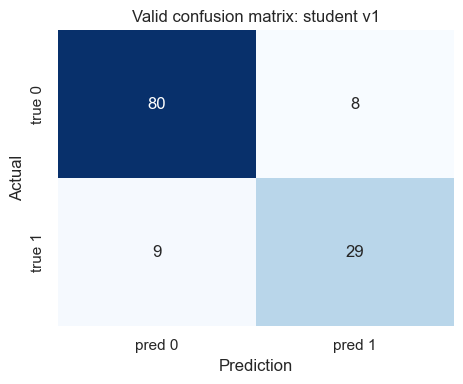

In [7]:
display(valid_student_v1_metrics)
plot_confusion(y_valid, valid_pred_v1, "Valid confusion matrix: student v1", FIG_DIR / "valid_student_v1_confusion_matrix.png")

valid_student_v1 = valid_df.copy()
valid_student_v1["student_score_v1"] = valid_score_v1
valid_student_v1["student_pred_v1"] = valid_pred_v1
valid_student_v1["student_score"] = valid_score_v1
valid_student_v1["student_pred"] = valid_pred_v1
valid_student_v1[["sample_id", "alert_flag", "student_score_v1", "student_pred_v1"]].to_csv(STUDENT_PRED_DIR / "valid_student_v1.csv", index=False)


Confusion matrix для `student v1` фиксирует baseline-ошибки на valid: модель даёт `8` false positives и `9` false negatives. Эти ошибки используются как основа для refined teacher prompt и дальнейшего сравнения с `student v2b`.


## 10. Error analysis student v1 на valid


In [8]:
ERROR_COLUMNS_V1 = [
    "sample_id", "title", "entity_norm", "text_fragment", "alert_flag", "student_pred_v1", "student_score_v1",
    "teacher_label_v1", "teacher_confidence_v1", "risk_type_4cls", "source", "published_year", "published_month", "text_length",
]
teacher_for_error_v1 = teacher_v1[["sample_id", "teacher_label", "teacher_confidence"]].rename(columns={
    "teacher_label": "teacher_label_v1",
    "teacher_confidence": "teacher_confidence_v1",
})
valid_student_v1 = valid_student_v1.merge(teacher_for_error_v1, on="sample_id", how="left")
ERROR_COLUMNS_V1 = [col for col in ERROR_COLUMNS_V1 if col in valid_student_v1.columns]

false_positives_valid_v1 = valid_student_v1[(valid_student_v1["alert_flag"] == 0) & (valid_student_v1["student_pred_v1"] == 1)].copy()
false_negatives_valid_v1 = valid_student_v1[(valid_student_v1["alert_flag"] == 1) & (valid_student_v1["student_pred_v1"] == 0)].copy()
true_positives_valid_v1 = valid_student_v1[(valid_student_v1["alert_flag"] == 1) & (valid_student_v1["student_pred_v1"] == 1)].copy()
true_negatives_valid_v1 = valid_student_v1[(valid_student_v1["alert_flag"] == 0) & (valid_student_v1["student_pred_v1"] == 0)].copy()

fp_count = len(false_positives_valid_v1)
fn_count = len(false_negatives_valid_v1)
fp_by_risk_type = false_positives_valid_v1["risk_type_4cls"].value_counts(dropna=False) if "risk_type_4cls" in false_positives_valid_v1 else pd.Series(dtype=int)
fn_by_risk_type = false_negatives_valid_v1["risk_type_4cls"].value_counts(dropna=False) if "risk_type_4cls" in false_negatives_valid_v1 else pd.Series(dtype=int)
high_conf_fp = false_positives_valid_v1.sort_values("student_score_v1", ascending=False).head(10)
high_conf_fn = false_negatives_valid_v1.sort_values("student_score_v1", ascending=True).head(10)

false_positives_valid_v1[ERROR_COLUMNS_V1].to_csv(ERROR_DIR / "valid_student_v1_false_positives.csv", index=False)
false_negatives_valid_v1[ERROR_COLUMNS_V1].to_csv(ERROR_DIR / "valid_student_v1_false_negatives.csv", index=False)

print("FP:", fp_count, "FN:", fn_count, "TP:", len(true_positives_valid_v1), "TN:", len(true_negatives_valid_v1))
print("FP by risk_type_4cls")
display(fp_by_risk_type)
print("FN by risk_type_4cls")
display(fn_by_risk_type)
print("High-confidence / high-score false positives")
display(high_conf_fp[ERROR_COLUMNS_V1])
print("High-confidence false negatives by low positive score")
display(high_conf_fn[ERROR_COLUMNS_V1])

valid_student_v1["error"] = (valid_student_v1["alert_flag"] != valid_student_v1["student_pred_v1"]).astype(int)
valid_student_v1["length_bin"] = pd.qcut(valid_student_v1["text_length"], q=4, duplicates="drop")
display(valid_student_v1.groupby("length_bin", observed=True).agg(
    n=("sample_id", "count"), errors=("error", "sum"), error_rate=("error", "mean"),
    mean_score=("student_score_v1", "mean"),
).reset_index())

if "source" in valid_student_v1.columns:
    display(valid_student_v1.groupby("source", dropna=False).agg(
        n=("sample_id", "count"), errors=("error", "sum"), error_rate=("error", "mean"),
    ).sort_values(["errors", "error_rate"], ascending=False).reset_index())


FP: 8 FN: 9 TP: 29 TN: 80
FP by risk_type_4cls


risk_type_4cls
no_risk    8
Name: count, dtype: int64

FN by risk_type_4cls


risk_type_4cls
regulatory_risk     6
cyber_risk          2
operational_risk    1
Name: count, dtype: int64

High-confidence / high-score false positives


,sample_id,title,entity_norm,text_fragment,alert_flag,student_pred_v1,student_score_v1,teacher_label_v1,teacher_confidence_v1,risk_type_4cls,source,published_year,published_month,text_length
18,ml_000119,«Яндекс.Деньги» ответили на данные о новом виде мошенничества с картами,Сбербанк,«Яндекс.Деньги» ответили на данные о новом виде мошенничества с картами В случае с кражами методами социальной инженерии сервис рекомендует проявлять бдительность при попытках обманом вывести денежные средства. Ранее...,0,1,0.768745,NaN,NaN,no_risk,telegram_contest,2019,11,535
93,ml_000619,Обслуживание карт Сбербанка осуществляется в штатном режиме,Сбербанк,"Обслуживание карт Сбербанка осуществляется в штатном режиме /ТАСС/. Сбербанк заявил о возобновлении обслуживания своих банковских карт. ""Действительно, были возможны кратковременные перерывы в совершении операций.",0,1,0.677313,NaN,NaN,no_risk,ods_tass,2015,11,213
59,ml_000403,Банкоматы ВТБ-24 возобновят прием пятитысячных купюр до конца октября,Промсвязьбанк,"Банкоматы ВТБ-24 возобновят прием пятитысячных купюр до конца октября В банке подтверждали временные ограничения, объясняя их техническими трудностями. nПятитысячные проблемыnКак ранее сообщал ИТАР-ТАСС, о временном ...",0,1,0.599762,NaN,NaN,no_risk,ods_tass,2013,10,488
114,ml_000751,Royal Bank of Scotland оштрафовали за лишение клиентов доступа к счетам,Сбербанк,"Royal Bank of Scotland оштрафовали за лишение клиентов доступа к счетам Компьютерные сбои часто затрагивают и российские банки. Например, Сбербанк 15 ноября признал очередной случай повторного списания средств со сче...",0,1,0.590493,NaN,NaN,no_risk,lenta,2014,11,432
106,ml_000702,Банкиры-нелегалы обналичили в Петербурге миллиарды рублей,Сбербанк,"Банкиры-нелегалы обналичили в Петербурге миллиарды рублей Были установлены четверо ее членов, десять фирм-однодневок, которые использовались в схеме, а также банки, через которые проводилось обналичивание средств. Пр...",0,1,0.578587,NaN,NaN,no_risk,lenta,2008,5,472
44,ml_000286,Банкиры-нелегалы обналичили в Петербурге миллиарды рублей,ВТБ,"Банкиры-нелегалы обналичили в Петербурге миллиарды рублей Были установлены четверо ее членов, десять фирм-однодневок, которые использовались в схеме, а также банки, через которые проводилось обналичивание средств. Пр...",0,1,0.569985,NaN,NaN,no_risk,lenta,2008,5,472
38,ml_000239,Райффайзенбанк сообщил об устранении неполадок с проведением операций по картам,Райффайзенбанк,"Райффайзенбанк сообщил об устранении неполадок с проведением операций по картам МОСКВА, 11 февраля. /ТАСС/.",0,1,0.566665,NaN,NaN,no_risk,ods_tass,2018,2,107
85,ml_000570,"Tele2 устранил сбой, который произошел в пяти городах",ВТБ,"Tele2 устранил сбой, который произошел в пяти городах nTele2 работает в 65 российских регионах. Ранее сообщалось, что акционеры Tele2 (""Ростелеком"" и ВТБ) обсуждают возможность запуска оператора в новых регионах.",0,1,0.545887,NaN,NaN,no_risk,ods_tass,2017,9,212


High-confidence false negatives by low positive score


,sample_id,title,entity_norm,text_fragment,alert_flag,student_pred_v1,student_score_v1,teacher_label_v1,teacher_confidence_v1,risk_type_4cls,source,published_year,published_month,text_length
72,ml_000512,"Почта банк отказался от исковых требований к ""Тинькофф банку""",Т-Банк,"Почта банк отказался от исковых требований к ""Тинькофф банку"" nДоговор между банками предоставляет право ""Тинькофф банку"" использовать бренд ""Лето"" на территории Санкт-Петербурга и Ленобласти при оплате вознаграждени...",1,0,0.198096,NaN,NaN,regulatory_risk,ods_tass,2018,3,495
33,ml_000202,Дворкович: власти договариваются с Китаем о финансировании для российских нефтяных компаний,ВТБ,"Дворкович: власти договариваются с Китаем о финансировании для российских нефтяных компаний Дворкович добавил, что правительство активно сотрудничает с финансовыми институтами «стран, не присоединившихся к санкциям» ...",1,0,0.248727,NaN,NaN,regulatory_risk,buriy,2014,10,602
30,ml_000193,Частные фирмы и предпринимателей могут обязать отвечать на запросы граждан,Сбербанк,"Частные фирмы и предпринимателей могут обязать отвечать на запросы граждан Это позволяет коммерческим структурам самостоятельно придумывать любые правила. Например, Сбербанк России считает возможным рассматривать обр...",1,0,0.305714,NaN,NaN,operational_risk,taiga_fontanka,2012,5,517
103,ml_000673,"США внесли Сбербанк, ВТБ, Лукойл и Роснефть в санкционный список",Газпромбанк,"США внесли Сбербанк, ВТБ, Лукойл и Роснефть в санкционный список Ограничения введены в отношении «Транснефти», «Газпрома», «Газпромнефти», «Лукойла», «Сургутнефтегаза», «Роснефти» и «Новатэка». В списке финансовых уч...",1,0,0.312495,NaN,NaN,regulatory_risk,buriy,2014,9,429
96,ml_000643,"США внесли Сбербанк, ВТБ, Лукойл и Роснефть в санкционный список",Россельхозбанк,"США внесли Сбербанк, ВТБ, Лукойл и Роснефть в санкционный список Ограничения введены в отношении «Транснефти», «Газпрома», «Газпромнефти», «Лукойла», «Сургутнефтегаза», «Роснефти» и «Новатэка». В списке финансовых уч...",1,0,0.325586,NaN,NaN,regulatory_risk,buriy,2014,9,429
109,ml_000722,В продаже появилась новая нелегальная база данных кредитных историй,Росбанк,"В продаже появилась новая нелегальная база данных кредитных историй Кроме того, мошенники предлагают информацию о банке, из которого была украдена информация. Известно, что в базе присутствуют данные из крупнейших ор...",1,0,0.401324,NaN,NaN,cyber_risk,lenta,2006,12,421
23,ml_000147,США предложили Китаю поддержать санкции против России,Россельхозбанк,"США предложили Китаю поддержать санкции против России При этом он заявил, что сожалеет о том, что дело дошло до санкций, и высказал пожелание, чтобы Москва и Вашингтон вернулись к «более конструктивным отношениям». В...",1,0,0.433283,NaN,NaN,regulatory_risk,lenta,2014,8,579
118,ml_000792,Суд поддержал карточный обман,ВТБ,"Суд поддержал карточный обман Мошенничество с карточкой Дмитрия Ильина – не первый подобный инцидент в Петербурге. Например, в январе 1999 года с дебетовой карточки «VISA Electron» клиента «Промышленно-строительного ...",1,0,0.451412,NaN,NaN,cyber_risk,taiga_fontanka,2008,8,497
11,ml_000062,Центробанк: финансовое положение подпавших под санкции банков остается устойчивым,Газпромбанк,"Центробанк: финансовое положение подпавших под санкции банков остается устойчивым nАктивы банков, подпавших под действие второй волны санкций, с начала июля выросли на 4,1%. n""В случае повышения рисков ликвидности ан...",1,0,0.468181,NaN,NaN,regulatory_risk,ods_tass,2014,10,641


,length_bin,n,errors,error_rate,mean_score
0,"(62.999, 345.75]",32,3,0.093750,0.409151
1,"(345.75, 431.5]",31,3,0.096774,0.359919
2,"(431.5, 549.0]",33,8,0.242424,0.391723
3,"(549.0, 1086.0]",30,3,0.100000,0.370582


,source,n,errors,error_rate
0,ods_tass,33,6,0.181818
1,lenta,28,5,0.178571
2,buriy,43,3,0.069767
3,taiga_fontanka,7,2,0.285714
4,telegram_contest,15,1,0.066667


## 11. Выводы по ошибкам student v1

Ошибки `student v1` могут быть связаны как с ограничениями TF-IDF-модели, так и с тем, как teacher prompt v1 сформировал soft-разметку train. Поэтому FP/FN на valid используются для уточнения refined teacher prompt `v2b`.

При доработке teacher prompt важно уменьшить ложные срабатывания на нейтральных упоминаниях банка, общем негативном фоне и общерыночных новостях, но не потерять косвенные риск-сигналы, где негативное событие действительно относится к банку.


## 12. Teacher prompt v2b, доработанный после ошибок v1

Teacher prompt `v2b` сформирован после анализа ошибок `student v1` на valid. Основная идея refined prompt — точнее отделять конкретные банковские риск-события от нейтральных упоминаний банка, общерыночного фона и внешних новостей без прямой связи с банком.

Такой prompt refinement проверяется через новую soft-разметку train и обучение `student v2b`, после чего качество сравнивается с `student v1` только на valid.


In [9]:
def build_llm_teacher_prompt_v2b(text):
    return f"""
Ты эксперт по банковскому риск-мониторингу.

Твоя задача — определить, содержит ли новостной фрагмент КОНКРЕТНЫЙ риск-сигнал именно для банка.

Верни строго JSON без дополнительного текста:

{{
  "label": 0 или 1,
  "confidence": число от 0.0 до 1.0
}}

Главное правило:
Ставь label = 1 только если в тексте есть конкретное негативное событие, которое относится к банку, его операциям, клиентским сервисам, регуляторному положению, санкционным ограничениям, судебным рискам, данным клиентов или репутации банка.

Ставь label = 1, если есть хотя бы один из признаков:

1. Киберриск:
- кибератака на банк, его сайт, приложение, инфраструктуру, банкоматы или процессинг;
- взлом банковских систем;
- компрометация банковских сервисов.

2. Утечка данных:
- утечка данных клиентов банка;
- утечка кредитных историй, карт, счетов, персональных или платёжных данных, если связь с банком или банковским сектором существенная.

3. Сбой банковских сервисов:
- недоступность мобильного банка, интернет-банка, карт, банкоматов, переводов, платежей;
- массовые задержки или невозможность обслуживания клиентов;
- сбой уже произошёл и затронул клиентов банка.

4. Санкции и ограничения:
- санкции против конкретного банка;
- ограничения операций банка;
- блокировка активов, счетов, карт, переводов или международных операций;
- банк включён в санкционный список.

5. Регуляторные, судебные и надзорные риски:
- проверка, претензия, иск, штраф, расследование или надзорные меры в отношении банка;
- судебный спор, где сам банк является стороной и событие может иметь последствия для банка.

6. Операционный или репутационный риск:
- событие может повлиять на устойчивость, репутацию, обслуживание клиентов или работу банка;
- публично описана проблема банка, а не просто рыночный фон.

Ставь label = 0, если явного риска именно для банка нет:

1. Нейтральное упоминание:
- банк просто упоминается как участник рынка, партнёр, кредитор, инвестор, эмитент, источник комментария или пример.

2. Общерыночный или макроэкономический контекст:
- новость про рынок, экономику, политику, отрасль или курс валют без конкретного негативного события для банка.

3. Внешний негатив:
- негатив относится к другой компании, клиенту, государству, телеком-оператору, отрасли или физическим лицам;
- банк только упомянут рядом, но событие не является проблемой банка.

4. Обычное мошенничество без проблемы банка:
- мошенники обманули клиента, но нет признаков сбоя, уязвимости или ответственности банковского сервиса;
- телефонное, бытовое или внешнее мошенничество без события на стороне банка.

5. Опровержение или отсутствие проблемы:
- текст говорит, что обслуживание идёт штатно;
- банк заявил об отсутствии опасности;
- проблема не подтвердилась;
- нет факта негативного события.

6. Реклама, продуктовая или справочная новость:
- запуск продукта, тариф, вакансия, рейтинг, комментарий, обычная сделка, партнёрство, отчётность без риск-события.

Правила для сложных случаев:

- Если текст сообщает о реальном сбое банковского сервиса, ставь label = 1, даже если банк потом объяснил причину.
- Если текст говорит только о том, что всё работает штатно или опасности нет, ставь label = 0.
- Если банк упомянут в новости о санкциях, но санкции направлены именно против банка — label = 1.
- Если санкции или ограничения относятся к другой организации, стране или отрасли, а банк только упомянут — label = 0.
- Если судебная или регуляторная история направлена против банка — label = 1.
- Если банк просто подал комментарий или фигурирует как справочный участник — label = 0.
- Если связь события с банком слабая или неоднозначная, снижай confidence.
- Если не уверен, что событие является риском именно для банка, лучше поставить label = 0 с умеренной confidence.

Примеры:

label = 1:
- "Банк объяснил сбой в мобильном приложении"
- "США внесли Сбербанк и ВТБ в санкционный список"
- "Часть карт банка перестала работать за рубежом из-за сбоя"
- "Регулятор проверяет операции банка"
- "В продаже появилась база данных кредитных историй"
- "Суд рассматривает претензии к банку"

label = 0:
- "Банк прокомментировал ситуацию на рынке"
- "Обслуживание карт банка осуществляется в штатном режиме"
- "Банк заявил об отсутствии опасности для клиентов"
- "Акции банковского сектора снизились без конкретной проблемы банка"
- "Мошенники позвонили клиенту, но нет сбоя или уязвимости банка"
- "Сбой произошёл у телеком-оператора, а банк только упомянут в тексте"

Текст:
{text}
"""


## 13. Загрузка или получение teacher labels v2b на train


In [10]:
teacher_v2b = load_or_run_teacher_labels(
    train_df,
    build_llm_teacher_prompt_v2b,
    TRAIN_TEACHER_V2B_CACHE,
    prompt_version="teacher_prompt_v2b",
    missing_cache_message=(
        "Teacher cache v2b not found. Set RUN_LLM_API=True to generate teacher labels v2b "
        "or put cache file into homework_07_postprocessing/reports/teacher_labels/."
    ),
)
display(teacher_v2b[["sample_id", "teacher_label", "teacher_confidence", "teacher_prompt_version"]].head())
display(teacher_v2b["teacher_label"].value_counts(dropna=False).rename("teacher_label_v2b_count"))


Loaded teacher cache: homework_07_postprocessing/reports/teacher_labels/train_teacher_prompt_v2b.csv


,sample_id,teacher_label,teacher_confidence,teacher_prompt_version
0,ml_000001,0,0.8,teacher_prompt_v2b
1,ml_000003,1,0.9,teacher_prompt_v2b
2,ml_000005,0,0.9,teacher_prompt_v2b
3,ml_000007,0,0.6,teacher_prompt_v2b
4,ml_000008,0,0.3,teacher_prompt_v2b


teacher_label
0    348
1    239
Name: teacher_label_v2b_count, dtype: int64

## 14. Преобразование teacher labels v2b в soft_y_v2b


In [11]:
train_teacher_v2b, teacher_soft_y_v2b = make_teacher_soft_labels(train_df, teacher_v2b)
print(f"v2b train rows with valid teacher labels: {len(train_teacher_v2b)}/{len(train_df)}")
display(pd.DataFrame({
    "teacher_soft_y_v2b": teacher_soft_y_v2b[:5],
    "alert_flag": train_teacher_v2b["alert_flag"].head().to_numpy(),
    "teacher_label_v2b": train_teacher_v2b["teacher_label"].head().to_numpy(),
    "teacher_confidence_v2b": train_teacher_v2b["teacher_confidence"].head().to_numpy(),
}))


v2b train rows with valid teacher labels: 587/587


,teacher_soft_y_v2b,alert_flag,teacher_label_v2b,teacher_confidence_v2b
0,0.2,0,0,0.8
1,0.9,0,1,0.9
2,0.1,0,0,0.9
3,0.4,0,0,0.6
4,0.7,0,0,0.3


## 15. Обучение student v2b


In [12]:
student_v2b, valid_score_v2b, valid_pred_v2b, valid_student_v2b_metrics, student_v2b_grid = train_best_student_from_teacher_soft(
    "LLM-distilled student v2b",
    train_teacher_v2b,
    teacher_soft_y_v2b,
)
display(student_v2b_grid)
student_v2b_grid.to_csv(ERROR_DIR / "student_v2b_alpha_c_grid_valid.csv", index=False)
print("Student v2b best alpha/C:", valid_student_v2b_metrics[["alpha", "C"]].iloc[0].to_dict())


,model_version,alpha,C,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
0,LLM-distilled student v2b,0.5,1.0,0.857143,0.738095,0.815789,0.775000,31,11,7,77,0.909988,0.823593
1,LLM-distilled student v2b,0.2,5.0,0.865079,0.818182,0.710526,0.760563,27,6,11,82,0.898923,0.811632
2,LLM-distilled student v2b,0.3,2.0,0.865079,0.818182,0.710526,0.760563,27,6,11,82,0.903708,0.817911
3,LLM-distilled student v2b,0.5,2.0,0.825397,0.666667,0.842105,0.744186,32,16,6,72,0.915969,0.838549
4,LLM-distilled student v2b,0.3,1.0,0.857143,0.812500,0.684211,0.742857,26,6,12,82,0.892644,0.801230
5,LLM-distilled student v2b,0.5,0.5,0.841270,0.736842,0.736842,0.736842,28,10,10,78,0.902811,0.807586
6,LLM-distilled student v2b,0.5,5.0,0.817460,0.653061,0.842105,0.735632,32,17,6,71,0.916866,0.842197
7,LLM-distilled student v2b,0.2,2.0,0.849206,0.806452,0.657895,0.724638,25,6,13,82,0.889055,0.802463
8,LLM-distilled student v2b,0.3,5.0,0.833333,0.729730,0.710526,0.720000,27,10,11,78,0.909091,0.824094
9,LLM-distilled student v2b,0.2,1.0,0.825397,0.807692,0.552632,0.656250,21,5,17,83,0.881280,0.789385


Student v2b best alpha/C: {'alpha': 0.5, 'C': 1.0}


## 16. Оценка student v2b на valid


,model_version,alpha,C,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
0,LLM-distilled student v2b,0.5,1.0,0.857143,0.738095,0.815789,0.775,31,11,7,77,0.909988,0.823593


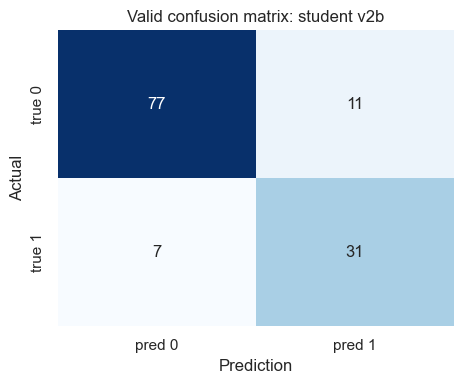

In [13]:
display(valid_student_v2b_metrics)
plot_confusion(y_valid, valid_pred_v2b, "Valid confusion matrix: student v2b", FIG_DIR / "valid_student_v2b_confusion_matrix.png")

valid_student_v2b = valid_df.copy()
valid_student_v2b["student_score_v2b"] = valid_score_v2b
valid_student_v2b["student_pred_v2b"] = valid_pred_v2b
valid_student_v2b["student_score"] = valid_score_v2b
valid_student_v2b["student_pred"] = valid_pred_v2b
valid_student_v2b[["sample_id", "alert_flag", "student_score_v2b", "student_pred_v2b"]].to_csv(STUDENT_PRED_DIR / "valid_student_v2b.csv", index=False)


По confusion matrix видно, что `student v2b` уменьшил число false negatives, но увеличил число false positives. Для риск-мониторинга это допустимый trade-off, если приоритетом является снижение пропущенных риск-сигналов. Однако рост false positives означает увеличение нагрузки на аналитика.


## 17. Сравнение student v1 vs student v2b


,model_version,alpha,C,precision,recall,f1,roc_auc,pr_auc,tp,fp,fn,tn,accuracy
0,LLM-distilled student v1,0.3,2.0,0.783784,0.763158,0.773333,0.900718,0.811464,29,8,9,80,0.865079
1,LLM-distilled student v2b,0.5,1.0,0.738095,0.815789,0.775000,0.909988,0.823593,31,11,7,77,0.857143


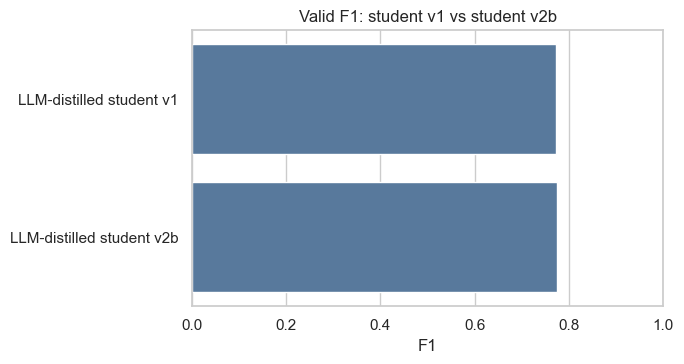

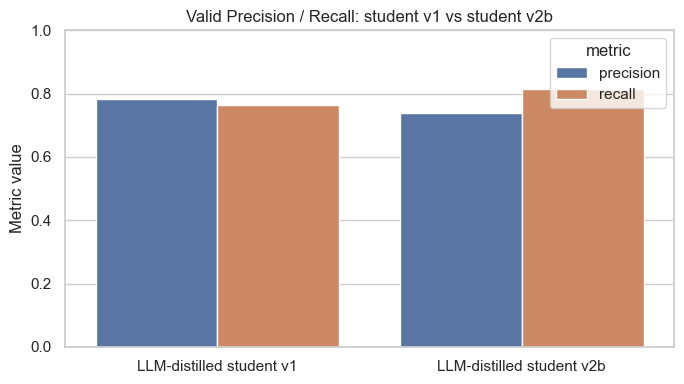

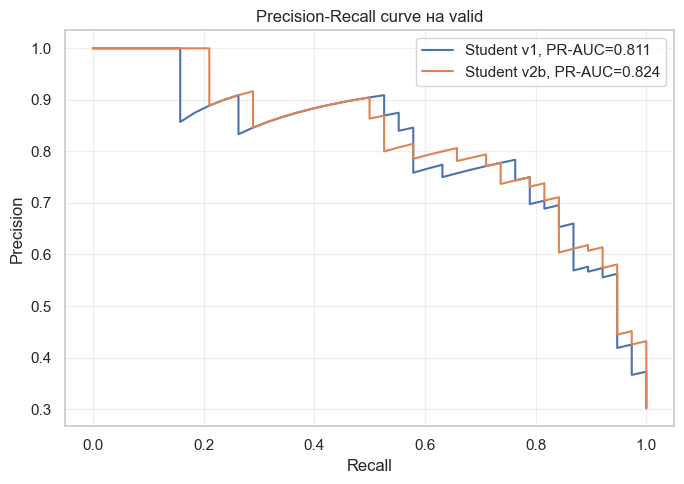

In [14]:
student_comparison = pd.concat([valid_student_v1_metrics, valid_student_v2b_metrics], ignore_index=True)
student_comparison = student_comparison[["model_version", "alpha", "C", "precision", "recall", "f1", "roc_auc", "pr_auc", "tp", "fp", "fn", "tn", "accuracy"]]
display(student_comparison)
student_comparison.to_csv(ERROR_DIR / "valid_student_v1_vs_v2b_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.barplot(data=student_comparison, y="model_version", x="f1", color="#4C78A8", ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Valid F1: student v1 vs student v2b")
ax.set_xlabel("F1")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "valid_student_f1_comparison_v1_v2b.png", dpi=160, bbox_inches="tight")
plt.show()

pr_plot = student_comparison.melt(id_vars="model_version", value_vars=["precision", "recall"], var_name="metric", value_name="value")
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pr_plot, x="model_version", y="value", hue="metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Valid Precision / Recall: student v1 vs student v2b")
ax.set_xlabel("")
ax.set_ylabel("Metric value")
fig.tight_layout()
fig.savefig(FIG_DIR / "valid_student_precision_recall_comparison_v1_v2b.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name, y_score in [("Student v1", valid_score_v1), ("Student v2b", valid_score_v2b)]:
    precision_curve, recall_curve, _ = precision_recall_curve(y_valid, y_score)
    ap = average_precision_score(y_valid, y_score)
    ax.plot(recall_curve, precision_curve, label=f"{name}, PR-AUC={ap:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve на valid")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "valid_student_v1_v2b_pr_curve.png", dpi=160, bbox_inches="tight")
plt.show()


f1_v1 = float(valid_student_v1_metrics["f1"].iloc[0])
f1_v2b = float(valid_student_v2b_metrics["f1"].iloc[0])
if f1_v2b >= f1_v1:
    final_student = student_v2b
    final_valid_score = valid_score_v2b
    final_valid_pred_05 = valid_pred_v2b
    final_model_name = "LLM-distilled student v2b"
else:
    final_student = student_v1
    final_valid_score = valid_score_v1
    final_valid_pred_05 = valid_pred_v1
    final_model_name = "LLM-distilled student v1"


По valid-метрикам для дальнейшей постобработки выбран `student v2b`, так как он немного улучшил F1 относительно `student v1`: `0.775` против `0.773`.

При этом улучшение нельзя считать однозначным по всем метрикам. `student v2b` повысил Recall и снизил число false negatives, то есть стал лучше находить риск-сигналы. Однако Precision снизился, а число false positives выросло. Это означает, что refined teacher prompt сделал student-модель более чувствительной к рискам, но ценой большего числа ложных алертов.

Дальнейшая postprocessing-настройка выполняется для `student v2b`, потому что он показал лучший valid F1. Test при этом не используется для выбора модели или threshold.

График Precision / Recall / F1 показывает, что `student v2b` смещает баланс модели в сторону Recall. Модель стала находить больше реальных риск-сигналов, но стала чаще поднимать ложные алерты. Поэтому основной эффект refined teacher prompt — повышение чувствительности модели, а не рост Precision.

PR-curve показывает качество ранжирования положительного класса при разных уровнях Recall и Precision. Для задачи риск-мониторинга PR-AUC особенно важна, потому что основной интерес представляет класс `alert_flag = 1`. У `student v2b` PR-AUC немного выше, что говорит о небольшом улучшении ранжирования риск-сигналов.


## 18. Постобработка финальной student-модели: подбор threshold


,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
0,0.30,0.357143,0.319328,1.000000,0.484076,38,81,0,7,0.909988,0.823593
1,0.35,0.515873,0.383838,1.000000,0.554745,38,61,0,27,0.909988,0.823593
2,0.40,0.658730,0.467532,0.947368,0.626087,36,41,2,47,0.909988,0.823593
3,0.45,0.793651,0.611111,0.868421,0.717391,33,21,5,67,0.909988,0.823593
4,0.50,0.857143,0.738095,0.815789,0.775000,31,11,7,77,0.909988,0.823593
5,0.55,0.841270,0.781250,0.657895,0.714286,25,7,13,81,0.909988,0.823593
6,0.60,0.825397,0.863636,0.500000,0.633333,19,3,19,85,0.909988,0.823593
7,0.65,0.777778,0.857143,0.315789,0.461538,12,2,26,86,0.909988,0.823593
8,0.70,0.746032,1.000000,0.157895,0.272727,6,0,32,88,0.909988,0.823593
9,0.75,0.738095,1.000000,0.131579,0.232558,5,0,33,88,0.909988,0.823593


Selected threshold by valid: 0.5


,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
4,0.5,0.857143,0.738095,0.815789,0.775,31.0,11.0,7.0,77.0,0.909988,0.823593


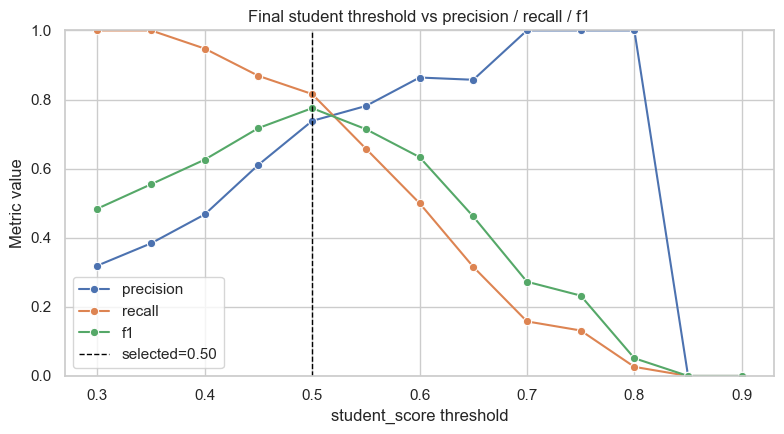

In [15]:
def evaluate_thresholds(score, y_true, thresholds):
    rows = []
    for threshold in thresholds:
        pred = (score >= threshold).astype(int)
        rows.append({"threshold": round(float(threshold), 2), **compute_binary_metrics(y_true, pred, score)})
    return pd.DataFrame(rows)


thresholds = np.arange(0.30, 0.91, 0.05)
threshold_results = evaluate_thresholds(final_valid_score, y_valid, thresholds)
display(threshold_results)
threshold_results.to_csv(ERROR_DIR / "valid_final_student_threshold_tuning.csv", index=False)

best_threshold_row = threshold_results.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
SELECTED_THRESHOLD = float(best_threshold_row["threshold"])
print("Selected threshold by valid:", SELECTED_THRESHOLD)
display(best_threshold_row.to_frame().T)

fig, ax = plt.subplots(figsize=(8, 4.5))
for metric in ["precision", "recall", "f1"]:
    sns.lineplot(data=threshold_results, x="threshold", y=metric, marker="o", label=metric, ax=ax)
ax.axvline(SELECTED_THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"selected={SELECTED_THRESHOLD:.2f}")
ax.set_ylim(0, 1)
ax.set_title("Final student threshold vs precision / recall / f1")
ax.set_xlabel("student_score threshold")
ax.set_ylabel("Metric value")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "valid_final_student_threshold_curve.png", dpi=160, bbox_inches="tight")
plt.show()


Threshold tuning был выполнен на valid. Лучшим по F1 оказался threshold `0.50`, то есть дополнительное ужесточение порога не улучшило full-coverage качество. При повышении threshold Precision может расти, но Recall падает слишком сильно, поэтому для финальной full-coverage схемы оставлен стандартный threshold `0.50`.


## 19. Постобработка финальной student-модели: review-zone


,review_threshold,coverage,review_rate,auto_errors,auto_precision,auto_recall,auto_f1
0,0.55,0.825397,0.174603,12,0.781250,0.833333,0.806452
1,0.60,0.563492,0.436508,5,0.863636,0.904762,0.883721
2,0.65,0.325397,0.674603,2,0.857143,1.000000,0.923077
3,0.70,0.103175,0.896825,0,1.000000,1.000000,1.000000
4,0.75,0.047619,0.952381,0,1.000000,1.000000,1.000000
5,0.80,0.007937,0.992063,0,1.000000,1.000000,1.000000


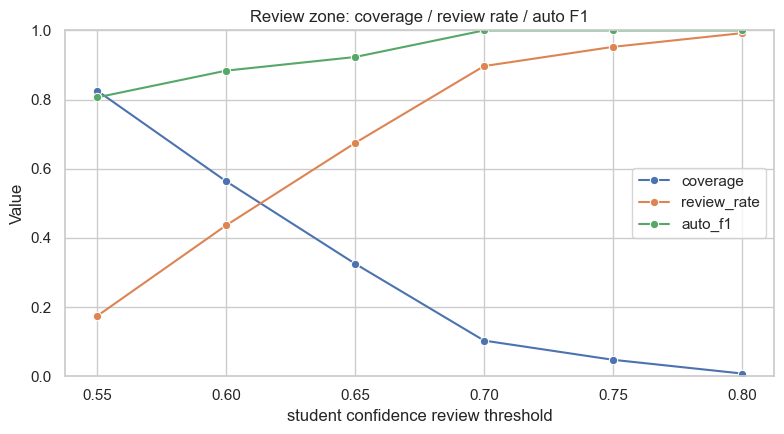

In [16]:
def evaluate_review_zone(score, pred, y_true, review_thresholds):
    student_confidence = np.maximum(score, 1 - score)
    rows = []
    for review_threshold in review_thresholds:
        auto_mask = student_confidence >= review_threshold
        row = {
            "review_threshold": review_threshold,
            "coverage": float(auto_mask.mean()),
            "review_rate": float((~auto_mask).mean()),
            "auto_errors": np.nan,
        }
        if auto_mask.sum() > 0:
            m = compute_binary_metrics(y_true[auto_mask], pred[auto_mask], score[auto_mask])
            row.update({
                "auto_precision": m["precision"],
                "auto_recall": m["recall"],
                "auto_f1": m["f1"],
                "auto_errors": m["fp"] + m["fn"],
            })
        else:
            row.update({"auto_precision": np.nan, "auto_recall": np.nan, "auto_f1": np.nan, "auto_errors": 0})
        rows.append(row)
    return pd.DataFrame(rows)


review_thresholds = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
review_results = evaluate_review_zone(final_valid_score, final_valid_pred_05, y_valid.values, review_thresholds)
display(review_results)
review_results.to_csv(ERROR_DIR / "valid_final_student_review_zone.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
for metric in ["coverage", "review_rate", "auto_f1"]:
    sns.lineplot(data=review_results, x="review_threshold", y=metric, marker="o", label=metric, ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Review zone: coverage / review rate / auto F1")
ax.set_xlabel("student confidence review threshold")
ax.set_ylabel("Value")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "valid_final_student_review_zone.png", dpi=160, bbox_inches="tight")
plt.show()


Review-zone был проверен на valid как возможный способ отделить менее уверенные предсказания для ручной проверки. В финальную full-coverage схему review-zone не добавлялся: выбранный вариант остаётся `student v2b + threshold 0.50`, а review-zone используется как диагностический анализ trade-off между coverage и ручной нагрузкой.


## 20. Выбор финальной схемы по valid


In [17]:
valid_pred_selected = (final_valid_score >= SELECTED_THRESHOLD).astype(int)
valid_final_selected_metrics = pd.DataFrame([{
    "model_version": f"{final_model_name} + threshold {SELECTED_THRESHOLD:.2f}",
    "alpha": np.nan,
    "C": np.nan,
    **compute_binary_metrics(y_valid, valid_pred_selected, final_valid_score),
}])

valid_full_comparison = pd.concat(
    [valid_student_v1_metrics, valid_student_v2b_metrics, valid_final_selected_metrics],
    ignore_index=True,
)[["model_version", "alpha", "C", "precision", "recall", "f1", "roc_auc", "pr_auc", "tp", "fp", "fn", "tn", "accuracy"]]
display(valid_full_comparison)
valid_full_comparison.to_csv(ERROR_DIR / "valid_student_full_comparison.csv", index=False)

print(f"Final scheme selected by valid: {final_model_name} + threshold {SELECTED_THRESHOLD:.2f}")


,model_version,alpha,C,precision,recall,f1,roc_auc,pr_auc,tp,fp,fn,tn,accuracy
0,LLM-distilled student v1,0.3,2.0,0.783784,0.763158,0.773333,0.900718,0.811464,29,8,9,80,0.865079
1,LLM-distilled student v2b,0.5,1.0,0.738095,0.815789,0.775000,0.909988,0.823593,31,11,7,77,0.857143
2,LLM-distilled student v2b + threshold 0.50,NaN,NaN,0.738095,0.815789,0.775000,0.909988,0.823593,31,11,7,77,0.857143


Final scheme selected by valid: LLM-distilled student v2b + threshold 0.50


Финальная схема выбирается только по valid. Test не используется для выбора threshold, review-zone или дальнейшей доработки prompt.

По valid-метрикам выбрана схема `student v2b + threshold 0.50`: она сохраняет лучший valid F1 среди проверенных вариантов. Это full-coverage схема без дополнительного review-фильтра, поэтому все test-объекты оцениваются автоматически по одному и тому же threshold.


## 21. Финальная проверка student v2b + postprocessing на test


,model_version,alpha,C,accuracy,precision,recall,f1,tp,fp,fn,tn,roc_auc,pr_auc
0,TEST LLM-distilled student v2b + threshold 0.50,NaN,NaN,0.888889,0.772727,0.894737,0.829268,34,10,4,78,0.9689,0.936073


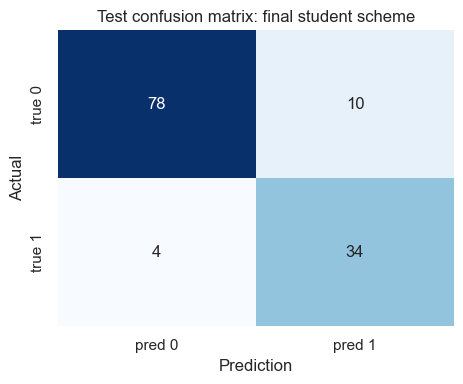

In [18]:
test_score_final = final_student.predict_proba(X_test_tfidf)[:, 1]
test_pred_final = (test_score_final >= SELECTED_THRESHOLD).astype(int)

test_final = test_df.copy()
test_final["student_score"] = test_score_final
test_final["student_pred"] = test_pred_final
test_final[["sample_id", "alert_flag", "student_score", "student_pred"]].to_csv(STUDENT_PRED_DIR / "test_student_final.csv", index=False)

test_final_metrics = pd.DataFrame([{
    "model_version": f"TEST {final_model_name} + threshold {SELECTED_THRESHOLD:.2f}",
    "alpha": np.nan,
    "C": np.nan,
    **compute_binary_metrics(y_test, test_pred_final, test_score_final),
}])
display(test_final_metrics)
test_final_metrics.to_csv(ERROR_DIR / "test_student_final_metrics.csv", index=False)
plot_confusion(y_test, test_pred_final, "Test confusion matrix: final student scheme", FIG_DIR / "test_student_final_confusion_matrix.png")


## 22. Test error analysis

На test финальная схема сохранила высокий Recall и хороший F1. Это означает, что модель в целом хорошо находит риск-сигналы. При этом остаются false positives и false negatives: false positives увеличивают нагрузку на аналитика, а false negatives являются наиболее критичными ошибками, потому что такие риск-сигналы не попадают в автоматический алерт.


In [19]:
TEST_ERROR_COLUMNS = [
    "sample_id", "title", "entity_norm", "text_fragment", "alert_flag", "student_pred", "student_score",
    "risk_type_4cls", "source", "published_year", "published_month", "text_length",
]
TEST_ERROR_COLUMNS = [col for col in TEST_ERROR_COLUMNS if col in test_final.columns]

false_positives_test_final = test_final[(test_final["alert_flag"] == 0) & (test_final["student_pred"] == 1)].copy()
false_negatives_test_final = test_final[(test_final["alert_flag"] == 1) & (test_final["student_pred"] == 0)].copy()

false_positives_test_final[TEST_ERROR_COLUMNS].to_csv(ERROR_DIR / "test_final_student_false_positives.csv", index=False)
false_negatives_test_final[TEST_ERROR_COLUMNS].to_csv(ERROR_DIR / "test_final_student_false_negatives.csv", index=False)

print("Test FP:", len(false_positives_test_final), "Test FN:", len(false_negatives_test_final))
print("Test false negatives")
display(false_negatives_test_final[TEST_ERROR_COLUMNS])
print("Test false positives")
display(false_positives_test_final[TEST_ERROR_COLUMNS].head(10))


Test FP: 10 Test FN: 4
Test false negatives


,sample_id,title,entity_norm,text_fragment,alert_flag,student_pred,student_score,risk_type_4cls,source,published_year,published_month,text_length
175,ml_000176,Банк «Открытие» объяснил сбой в мобильном приложении,Банк Открытие,"Банк «Открытие» объяснил сбой в мобильном приложении Банк «ФК Открытие» объяснил проблемы со входом в приложение обновлением программного обеспечения. В настоящее время мобильный банк работает в штатном режиме, сообщ...",1,0,0.499824,operational_risk,telegram_contest,2019,11,255
459,ml_000460,СМИ: В дни максимальной волатильности рубля Сбербанк столкнулся с массовым оттоком вкладов,Сбербанк,"СМИ: В дни максимальной волатильности рубля Сбербанк столкнулся с массовым оттоком вкладов Сбербанк столкнулся с массовым оттоком денег вкладчиков, сообщают «Ведомости», ссылаясь на источник, близкий к руководству Сб...",1,0,0.435522,operational_risk,taiga_fontanka,2014,12,309
802,ml_000803,Сыктывкарка «сохранила» 150 тысяч рублей на счету мошенников,Почта Банк,Сыктывкарка «сохранила» 150 тысяч рублей на счету мошенников По факту инцидента завели уголовное дело. #мошенничество#сыктывкар#почта банк,1,0,0.494692,cyber_risk,telegram_contest,2019,11,138
812,ml_000813,ОНФ просит проверить Россельхозбанк на мошенничество в сфере кредитования,Россельхозбанк,"ОНФ просит проверить Россельхозбанк на мошенничество в сфере кредитования КРАСНОДАР, 10 апреля. /Корр. ТАСС Сергей Околов/.",1,0,0.489731,cyber_risk,ods_tass,2017,4,123


Test false positives


,sample_id,title,entity_norm,text_fragment,alert_flag,student_pred,student_score,risk_type_4cls,source,published_year,published_month,text_length
77,ml_000078,Сбербанк опровергает проблемы с обслуживанием своих карт в Петербурге,Сбербанк,"Сбербанк опровергает проблемы с обслуживанием своих карт в Петербурге ""По Петербургу никаких жалоб не поступало"", - так ответили корреспонденту ""Фонтанки"" в справочной Сбербанка на вопрос о том, имеются ли в города п...",0,1,0.527152,no_risk,taiga_fontanka,2013,8,376
309,ml_000310,Сбербанк объявил о новом компьютерном сбое,Сбербанк,Сбербанк объявил о новом компьютерном сбое Заявки инвесторов на ММВБ с 9:30 по московскому времени 20 августа 2009 года выставляются с задержками из-за сбоя в аппаратно-программном комплексе проведения брокерских опе...,0,1,0.559514,no_risk,lenta,2009,8,289
367,ml_000368,"Улюкаев не исключил оказания поддержки компаниям, попавшим под санкции Украины",Газпромбанк,"Улюкаев не исключил оказания поддержки компаниям, попавшим под санкции Украины Так, в список попали «Трансаэро», «Уральские авиалинии», «Аэрофлот», «Сибирь», «Оренбургские авиалинии» и «Газпромавиа». Среди банков под...",0,1,0.517020,no_risk,buriy,2015,9,438
432,ml_000433,Украинский Сбербанк заявил об отсутствии опасности для интересов клиентов,ВТБ,"Украинский Сбербанк заявил об отсутствии опасности для интересов клиентов Ограничения будут действовать один год. Санкции применяются к украинскому Сбербанку, Виесте Банку, Акционерному коммерческому промышленно-инве...",0,1,0.583769,no_risk,lenta,2017,3,372
483,ml_000484,Справка о компании Тинькофф Банк,Т-Банк,"Справка о компании Тинькофф Банк Продуктовая линейка банка включает кредитные, дебетовые и предоплаченные карты, депозиты, кобрендовые карты, а также ипотечные продукты по агентской схеме. Банк уделяет большое вниман...",0,1,0.508934,no_risk,taiga_fontanka,2016,8,409
562,ml_000563,Сбербанк пригрозил ММВБ-РТС взысканием ущерба за технический сбой,Сбербанк,Сбербанк пригрозил ММВБ-РТС взысканием ущерба за технический сбой Сбербанк может потребовать с ММВБ возмещения ущерба в связи с произошедшим 19 декабря техническим сбоем на вечерних торгах объединенной биржи ММВБ-РТС...,0,1,0.604766,no_risk,lenta,2011,12,350
568,ml_000569,Бывший президент «Балтийского банка» объявлен в розыск за хищение 3 млрд рублей,Альфа-Банк,"Бывший президент «Балтийского банка» объявлен в розыск за хищение 3 млрд рублей В августе прошлого года Центробанк принял решение провести санацию «Балтийского банка», в ходе которой кредитное учреждение получило 57,...",0,1,0.511103,no_risk,buriy,2015,4,306
593,ml_000594,Альфа-банк решил публиковать переписку с недовольными клиентами,ВТБ,"Альфа-банк решил публиковать переписку с недовольными клиентами Газета пишет, что банк и раньше старался отслеживать мнения клиентов на разных ресурсах в интернете, но новый сайт позволит оперативнее получать информа...",0,1,0.512207,no_risk,lenta,2010,10,454
741,ml_000742,"Украинская ""дочка"" UniCredit Bank снова ввела лимиты на снятие средств в банкоматах",Сбербанк,"Украинская ""дочка"" UniCredit Bank снова ввела лимиты на снятие средств в банкоматах Помимо UniCredit Bank ограничения ввел ряд других украинских банков. В частности, о таких мерах официально сообщили Сбербанк, Приват...",0,1,0.546216,no_risk,ods_tass,2014,3,278
768,ml_000769,Банковские мошенники стали чаще звонить по телефону,Райффайзенбанк,"Банковские мошенники стали чаще звонить по телефону Об этом подробно рассказали специалисты. Райффайзенбанк и «Лаборатория Касперского» подготовили совместное исследование, в котором говорится, что снижение числа мош...",0,1,0.512235,no_risk,telegram_contest,2019,11,689


## 23. Подробный анализ качества модели в разрезе метрик


In [20]:
metric_interpretation = pd.DataFrame([
    {"Метрика": "Precision", "Что показывает": "Долю student alerts, которые действительно являются риск-сигналами.", "Почему важна в риск-мониторинге": "Низкий Precision перегружает аналитиков ложными алертами.", "Как интерпретировать": "Чем выше, тем меньше FP среди поднятых student alerts."},
    {"Метрика": "Recall", "Что показывает": "Долю реальных риск-сигналов, найденных student-моделью.", "Почему важна в риск-мониторинге": "FN означают пропущенные риск-события.", "Как интерпретировать": "Чем выше, тем меньше пропусков положительного класса."},
    {"Метрика": "F1", "Что показывает": "Баланс Precision и Recall.", "Почему важна в риск-мониторинге": "Помогает выбирать threshold без экстремального перекоса.", "Как интерпретировать": "Удобна для сравнения student v1/v2 и postprocessing на valid."},
    {"Метрика": "ROC-AUC", "Что показывает": "Способность student_score разделять классы по всем порогам.", "Почему важна в риск-мониторинге": "Показывает качество ранжирования до выбора threshold.", "Как интерпретировать": "Ближе к 1 — лучше разделение классов."},
    {"Метрика": "PR-AUC", "Что показывает": "Качество ранжирования положительного класса.", "Почему важна в риск-мониторинге": "Фокусируется на risk-signal классе при дисбалансе.", "Как интерпретировать": "Чем выше, тем лучше student поднимает риски вверх."},
    {"Метрика": "Confusion matrix", "Что показывает": "TP, FP, FN, TN.", "Почему важна в риск-мониторинге": "Разделяет пропуски рисков и лишние алерты.", "Как интерпретировать": "FN наиболее критичны, FP создают нагрузку."},
    {"Метрика": "student_score", "Что показывает": "Вероятность класса alert_flag=1 по student-модели.", "Почему важна в риск-мониторинге": "Основа для threshold tuning и review zone.", "Как интерпретировать": "Не идеально калиброванная вероятность, но полезный ranking score."},
    {"Метрика": "Threshold", "Что показывает": "Правило перевода student_score в label.", "Почему важна в риск-мониторинге": "Управляет Precision/Recall trade-off.", "Как интерпретировать": "Более высокий threshold обычно снижает FP и повышает FN."},
    {"Метрика": "Review zone", "Что показывает": "Долю объектов, отправленных на manual review.", "Почему важна в риск-мониторинге": "Снижает риск автоматических ошибок.", "Как интерпретировать": "Увеличивает ручную нагрузку и снижает coverage."},
])
display(metric_interpretation)
metric_interpretation.to_csv(ERROR_DIR / "student_metric_interpretation.csv", index=False)


,Метрика,Что показывает,Почему важна в риск-мониторинге,Как интерпретировать
0,Precision,"Долю student alerts, которые действительно являются риск-сигналами.",Низкий Precision перегружает аналитиков ложными алертами.,"Чем выше, тем меньше FP среди поднятых student alerts."
1,Recall,"Долю реальных риск-сигналов, найденных student-моделью.",FN означают пропущенные риск-события.,"Чем выше, тем меньше пропусков положительного класса."
2,F1,Баланс Precision и Recall.,Помогает выбирать threshold без экстремального перекоса.,Удобна для сравнения student v1/v2 и postprocessing на valid.
3,ROC-AUC,Способность student_score разделять классы по всем порогам.,Показывает качество ранжирования до выбора threshold.,Ближе к 1 — лучше разделение классов.
4,PR-AUC,Качество ранжирования положительного класса.,Фокусируется на risk-signal классе при дисбалансе.,"Чем выше, тем лучше student поднимает риски вверх."
5,Confusion matrix,"TP, FP, FN, TN.",Разделяет пропуски рисков и лишние алерты.,"FN наиболее критичны, FP создают нагрузку."
6,student_score,Вероятность класса alert_flag=1 по student-модели.,Основа для threshold tuning и review zone.,"Не идеально калиброванная вероятность, но полезный ranking score."
7,Threshold,Правило перевода student_score в label.,Управляет Precision/Recall trade-off.,Более высокий threshold обычно снижает FP и повышает FN.
8,Review zone,"Долю объектов, отправленных на manual review.",Снижает риск автоматических ошибок.,Увеличивает ручную нагрузку и снижает coverage.


## 24. Итоговая сводная таблица


In [21]:
valid_summary = valid_full_comparison.copy()
valid_summary["dataset"] = "valid"
valid_summary["scheme"] = valid_summary["model_version"].replace({
    "LLM-distilled student v1": "student v1 threshold 0.50",
    "LLM-distilled student v2b": "student v2b threshold 0.50",
    f"{final_model_name} + threshold {SELECTED_THRESHOLD:.2f}": f"{final_model_name} selected threshold {SELECTED_THRESHOLD:.2f}",
})
valid_summary["threshold"] = np.where(valid_summary["scheme"].str.contains("selected"), SELECTED_THRESHOLD, 0.5)

test_summary = test_final_metrics.copy()
test_summary["dataset"] = "test"
test_summary["scheme"] = f"{final_model_name} selected threshold {SELECTED_THRESHOLD:.2f}"
test_summary["threshold"] = SELECTED_THRESHOLD

final_summary_table = pd.concat([valid_summary, test_summary], ignore_index=True)
final_summary_table = final_summary_table[[
    "dataset", "scheme", "threshold", "precision", "recall", "f1", "roc_auc", "pr_auc", "tp", "fp", "fn", "tn",
]]
display(final_summary_table)
final_summary_table.to_csv(ERROR_DIR / "student_final_summary_table.csv", index=False)


,dataset,scheme,threshold,precision,recall,f1,roc_auc,pr_auc,tp,fp,fn,tn
0,valid,student v1 threshold 0.50,0.5,0.783784,0.763158,0.773333,0.900718,0.811464,29,8,9,80
1,valid,student v2b threshold 0.50,0.5,0.738095,0.815789,0.775000,0.909988,0.823593,31,11,7,77
2,valid,LLM-distilled student v2b selected threshold 0.50,0.5,0.738095,0.815789,0.775000,0.909988,0.823593,31,11,7,77
3,test,LLM-distilled student v2b selected threshold 0.50,0.5,0.772727,0.894737,0.829268,0.968900,0.936073,34,10,4,78


Так как threshold tuning выбрал `0.50`, финальная full-coverage схема совпадает с базовым threshold `0.50` для `student v2b`. Поэтому строки `student v2b threshold 0.50` и `student v2b selected threshold 0.50` показывают один и тот же рабочий порог, но вторая строка фиксирует его как выбранный по valid threshold для финальной схемы.


## 25. Финальные выводы и ограничения

### Финальные выводы

В работе был выполнен полный цикл LLM-distillation prompt refinement: baseline teacher prompt использовался для teacher-разметки train, после чего была обучена student-модель. Затем по ошибкам `student v1` на valid был сформирован refined teacher prompt, на основе которого была получена новая soft-разметка и обучен `student v2b`.

`Student v2b` показал небольшой прирост F1, Recall, ROC-AUC и PR-AUC на valid, но ценой снижения Precision и роста false positives. Поэтому результат prompt refinement интерпретируется как recall-oriented улучшение, а не как универсальное улучшение всех метрик.

Postprocessing через threshold tuning был проверен на valid. Лучшим threshold по F1 оказался `0.50`, поэтому дополнительное ужесточение порога не применялось. Test использовался только для финальной проверки выбранной схемы.

### Подробный анализ качества

Ключевые метрики для риск-мониторинга — Recall, Precision, F1, ROC-AUC и PR-AUC. На valid финальный `student v2b` даёт Precision около `0.738`, Recall около `0.816`, F1 около `0.775`, ROC-AUC около `0.910` и PR-AUC около `0.824`. Confusion matrix на valid: TP `31`, FP `11`, FN `7`, TN `77`.

На test финальная схема `student v2b + threshold 0.50` даёт Precision около `0.773`, Recall около `0.895`, F1 около `0.829`, ROC-AUC около `0.969` и PR-AUC около `0.936`. Confusion matrix на test: TP `34`, FP `10`, FN `4`, TN `78`.

Финальная схема применяется к test только после выбора student и threshold по valid. Test не используется для доработки prompt, alpha, C, threshold или review-zone.

### Ограничения

- teacher labels генерируются только для train;
- качество student зависит от качества teacher-разметки;
- TF-IDF student может терять часть семантики;
- улучшение `student v2b` над `student v1` по valid F1 небольшое, поэтому результат нужно интерпретировать как recall-oriented улучшение, а не как радикальную смену качества.
